In [1]:
# %%
# ============================================================
# 10회차 실습 코드 - 파트 1: 회귀 진단
# "내 회귀 결과, 믿어도 될까?"
# ============================================================
# 구글 Colab에서 실행합니다.
# 셀은 # %% 로 구분되어 있으며, 위에서 아래로 순서대로 실행하세요.
# ============================================================

# %% [셀 1] 라이브러리 불러오기
# -----------------------------------------------------------
# 분석에 필요한 도구들을 먼저 불러옵니다.
# 파이썬은 혼자 모든 걸 할 수 없고, 목적에 맞는 도구(라이브러리)를 가져와 씁니다.
# !pip install statsmodels

import pandas as pd               # 데이터를 표(DataFrame) 형태로 다루는 도구
import numpy as np                # 수학 계산을 빠르게 해주는 도구
import matplotlib.pyplot as plt   # 그래프를 그리는 도구
import statsmodels.api as sm      # 회귀분석 및 통계 검정 도구

print("라이브러리 로드 완료!")



라이브러리 로드 완료!


In [ ]:

# %% [셀 2] 데이터 불러오기
# -----------------------------------------------------------
# 구글 Colab에서는 아래 두 가지 방법 중 하나로 파일을 불러옵니다.
#
# 방법 A: 구글 드라이브에 파일을 올려둔 경우
#   from google.colab import drive
#   drive.mount('/content/drive')
#   df = pd.read_csv('/content/drive/MyDrive/data.csv')
#
# 방법 B: 직접 업로드하는 경우
#   from google.colab import files
#   uploaded = files.upload()   # 버튼이 뜨면 data.csv 선택
#   df = pd.read_csv('data.csv')
#
# 아래는 방법 B 기준으로 작성합니다. 드라이브를 쓴다면 위 방법 A로 바꾸세요.

# from google.colab import files
# uploaded = files.upload()   # 실행하면 파일 선택 버튼이 나옵니다 → data.csv 선택
df = pd.read_csv('data.csv')

# 컬럼명 앞뒤 공백 제거 (data.csv에 공백이 포함된 컬럼명이 있음)
df.columns = df.columns.str.strip()

# 날짜 컬럼을 파이썬이 날짜로 인식하도록 변환
df['Date'] = pd.to_datetime(df['Date'])

# 데이터가 잘 들어왔는지 첫 5행 확인
print(f"데이터 크기: {df.shape}")   # (행 수, 열 수)
print(f"기간: {df['Date'].min().date()} ~ {df['Date'].max().date()}")
print()
print(df.head())


데이터 크기: (132, 9)
기간: 2015-01-01 ~ 2025-12-01

        Date   Ulsan  Daesan  Gwangyang  Oil_Price  Ex_Rate  Chem_Prod  \
0 2015-01-01  1452.1   721.4     1125.0       47.3     1088       92.5   
1 2015-02-01  1332.2   660.5     1030.4       54.2     1095       92.1   
2 2015-03-01  1489.2   739.5     1154.6       52.5     1112       92.8   
3 2015-04-01  1489.7   738.3     1156.4       57.1     1085       93.4   
4 2015-05-01  1526.4   760.1     1184.5       62.3     1090       93.8   

   Freight_Idx  Global_Idx  
0          850        99.8  
1          845        99.7  
2          830        99.9  
3          815       100.2  
4          800       100.5  


: 

In [7]:

# %% [셀 3] 9회차 복습 - OLS 회귀 다시 돌리기
# -----------------------------------------------------------
# 오늘 잔차 분석을 하려면 먼저 회귀모델이 있어야 합니다.
# 9회차에서 했던 것과 동일한 모델을 여기서 다시 만듭니다.
#
# [모델 설명]
# Y (종속변수): Ulsan (울산항 월별 물동량)
# X (독립변수): Oil_Price (유가), Ex_Rate (환율)

# 독립변수 X 설정 (상수항 추가: 절편을 모델에 포함시키기 위함)
X = sm.add_constant(df[['Oil_Price', 'Ex_Rate']])

# 종속변수 Y 설정
y = df['Ulsan']

# OLS 회귀 실행
model = sm.OLS(y, X).fit()

# 결과 요약 출력 (9회차에서 읽었던 그 표)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Ulsan   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     11.89
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.82e-05
Time:                        05:35:52   Log-Likelihood:                -777.50
No. Observations:                 132   AIC:                             1561.
Df Residuals:                     129   BIC:                             1570.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1287.6780     98.566     13.064      0.0

In [8]:

# %% [셀 4] 잔차 추출하기
# -----------------------------------------------------------
# 모델이 만들어졌으면, 잔차를 꺼냅니다.
# 잔차 = 실제값 - 예측값
# 즉, "모델이 얼마나 틀렸는가"를 나타냅니다.

# 예측값 추출
y_pred = model.fittedvalues   # 모델이 예측한 값들

# 잔차 추출 (.resid = residuals의 약자)
residuals = model.resid       # 잔차 = 실제값 - 예측값

# 잔차 기본 정보 확인
print("=== 잔차 기본 통계 ===")
print(f"평균: {residuals.mean():.4f}")      # 0에 가까워야 정상
print(f"표준편차: {residuals.std():.2f}")
print(f"최솟값: {residuals.min():.2f}")    # 크게 음수인 점 = 이상치 후보
print(f"최댓값: {residuals.max():.2f}")    # 크게 양수인 점 = 이상치 후보
print()

# 잔차가 가장 큰 5개, 가장 작은 5개 시점 확인
df_resid = pd.DataFrame({
    'Date': df['Date'],
    'Actual': y,
    'Predicted': y_pred,
    'Residual': residuals
})

print("=== 잔차 절댓값이 가장 큰 상위 5개 시점 ===")
print(df_resid.reindex(df_resid['Residual'].abs().nlargest(5).index)
      .to_string(index=False))


=== 잔차 기본 통계 ===
평균: -0.0000
표준편차: 87.80
최솟값: -280.35
최댓값: 161.78

=== 잔차 절댓값이 가장 큰 상위 5개 시점 ===
      Date  Actual   Predicted    Residual
2020-04-01  1150.2 1430.547780 -280.347780
2022-06-01  1335.2 1602.724307 -267.524307
2020-05-01  1185.7 1449.750829 -264.050829
2022-03-01  1370.5 1587.313659 -216.813659
2022-04-01  1385.4 1577.681905 -192.281905


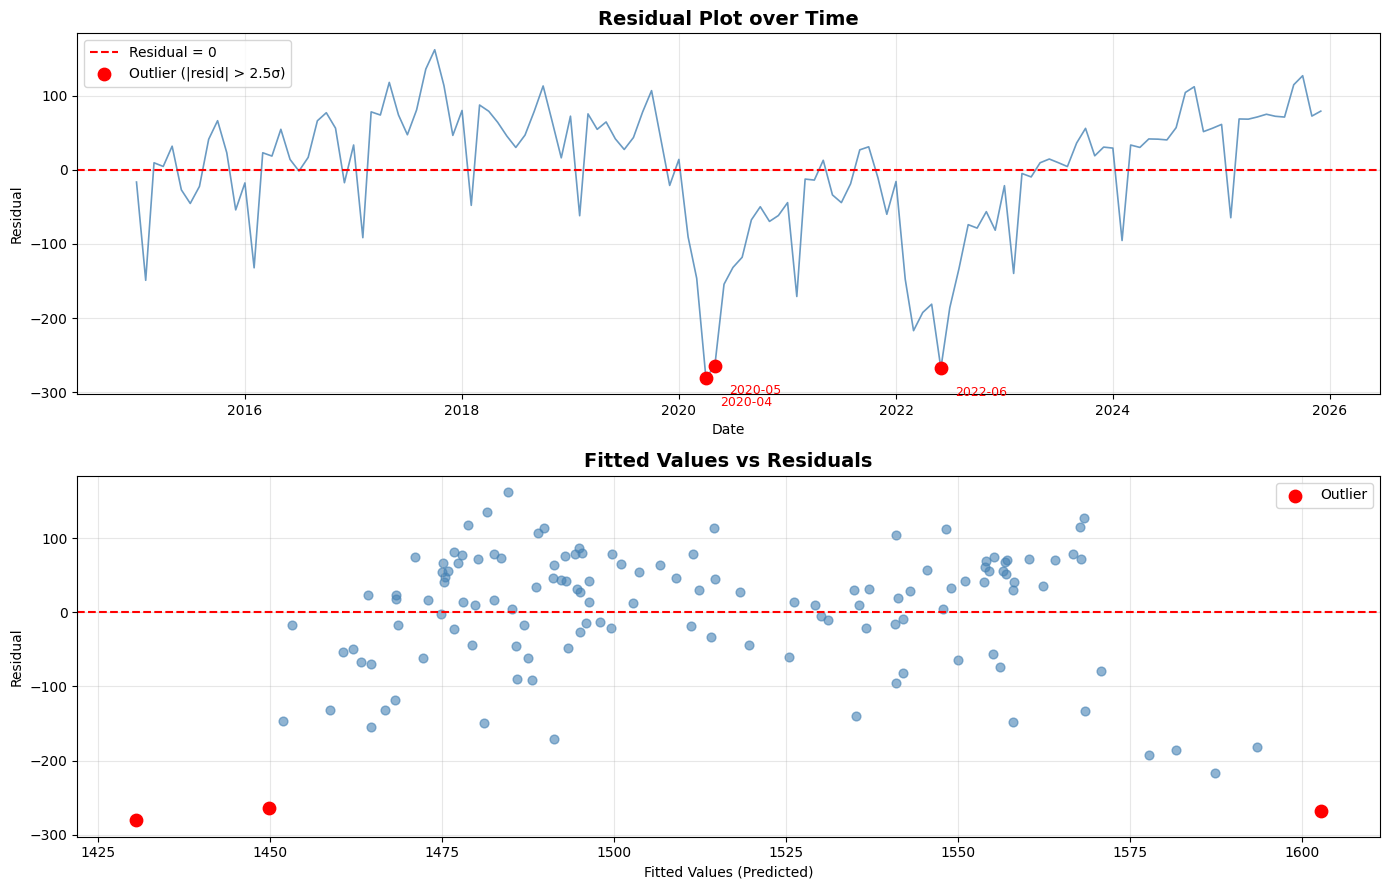


[그래프 해석 포인트]
위 그래프: 시간에 따라 잔차 패턴이 있는가? 크게 튀는 점은?
아래 그래프: 예측값과 무관하게 잔차가 고르게 퍼져 있는가?


In [9]:

# %% [셀 5] 잔차 플롯 그리기 - 핵심 시각화
# -----------------------------------------------------------
# 잔차를 시간 순서로 그래프로 그립니다.
# 이 그래프 하나로 모델의 문제점 대부분을 발견할 수 있습니다.
#
# [보는 방법]
# - 점들이 0 근처에서 랜덤하게 흩어져 있어야 → 좋은 모델
# - 파도처럼 패턴이 보이면 → 자기상관 의심
# - 특정 점이 크게 튀면 → 이상치

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- 위 그래프: 잔차 시계열 플롯 ---
axes[0].plot(df['Date'], residuals,
             color='steelblue', linewidth=1.2, alpha=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5,
                label='Residual = 0')

# 이상치 강조: 잔차가 표준편차의 2.5배 이상인 점은 빨간 점으로 표시
threshold = 2.5 * residuals.std()
outlier_mask = residuals.abs() > threshold
axes[0].scatter(df['Date'][outlier_mask], residuals[outlier_mask],
                color='red', zorder=5, s=80, label='Outlier (|resid| > 2.5σ)')

# 이상치 날짜에 라벨 붙이기
for idx in df['Date'][outlier_mask].index:
    axes[0].annotate(df['Date'][idx].strftime('%Y-%m'),
                     xy=(df['Date'][idx], residuals[idx]),
                     xytext=(10, -20), textcoords='offset points',
                     fontsize=9, color='red')

axes[0].set_title('Residual Plot over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 아래 그래프: 예측값 vs 잔차 (Fitted vs Residual) ---
# X축: 예측값 / Y축: 잔차
# 이 그래프에서 패턴이 보이면 등분산성 위반을 의심합니다.
axes[1].scatter(y_pred, residuals,
                color='steelblue', alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].scatter(y_pred[outlier_mask], residuals[outlier_mask],
                color='red', zorder=5, s=80, label='Outlier')
axes[1].set_title('Fitted Values vs Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fitted Values (Predicted)')
axes[1].set_ylabel('Residual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[그래프 해석 포인트]")
print("위 그래프: 시간에 따라 잔차 패턴이 있는가? 크게 튀는 점은?")
print("아래 그래프: 예측값과 무관하게 잔차가 고르게 퍼져 있는가?")


In [10]:

# %% [셀 6] 자기상관 수치 확인 - Durbin-Watson
# -----------------------------------------------------------
# 자기상관을 하나의 숫자로 요약합니다.
#
# Durbin-Watson 통계량 해석:
#   0 근처: 강한 양의 자기상관 (이번 잔차 크면 다음도 큼)
#   2 근처: 자기상관 없음 (이상적)
#   4 근처: 강한 음의 자기상관
#
# 일반적으로 1.5 ~ 2.5 사이면 문제없다고 봅니다.

from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(residuals)

print(f"Durbin-Watson 통계량: {dw_stat:.4f}")
print()

if dw_stat < 1.5:
    print("→ 양의 자기상관이 의심됩니다.")
    print("  이번 달 잔차가 크면 다음 달도 클 가능성이 높다는 뜻입니다.")
    print("  p-value가 실제보다 작게 보일 수 있습니다.")
elif dw_stat > 2.5:
    print("→ 음의 자기상관이 의심됩니다.")
else:
    print("→ 자기상관 문제 없음. OLS 가정이 충족됩니다.")


Durbin-Watson 통계량: 0.5275

→ 양의 자기상관이 의심됩니다.
  이번 달 잔차가 크면 다음 달도 클 가능성이 높다는 뜻입니다.
  p-value가 실제보다 작게 보일 수 있습니다.


In [11]:

# %% [셀 7] 이상치 처리 - 더미변수 추가해보기
# -----------------------------------------------------------
# 이상치를 발견했을 때 가장 깔끔한 처리 방법 중 하나는
# 더미변수(Dummy Variable)를 만드는 것입니다.
#
# 더미변수란?
# 특정 조건에서 1, 나머지는 0을 넣는 변수입니다.
# "코로나 충격 기간에는 1, 아니면 0" 같은 식입니다.
# 이 변수를 모델에 추가하면 그 기간의 충격을 통제할 수 있습니다.

# 2020년을 코로나 더미로 설정 (2020년이면 1, 아니면 0)
df['COVID_dummy'] = (df['Date'].dt.year == 2020).astype(int)

print("더미변수 확인 (2020년만 1이 됩니다):")
print(df[df['COVID_dummy'] == 1][['Date', 'COVID_dummy', 'Ulsan', 'Oil_Price']].to_string(index=False))

# 더미변수를 포함한 새 모델
X_dummy = sm.add_constant(df[['Oil_Price', 'Ex_Rate', 'COVID_dummy']])
model_dummy = sm.OLS(y, X_dummy).fit()

print("\n=== 더미변수 추가 모델 결과 ===")
print(model_dummy.summary())

# 두 모델의 R² 비교
print("\n=== 모델 비교 ===")
print(f"기본 모델 R²:        {model.rsquared:.4f}")
print(f"더미 추가 모델 R²:   {model_dummy.rsquared:.4f}")
print(f"R² 개선:             {model_dummy.rsquared - model.rsquared:+.4f}")
print()
print("R²가 올라갔다면, 코로나 충격을 통제함으로써")
print("모델의 설명력이 향상되었다는 의미입니다.")


더미변수 확인 (2020년만 1이 됩니다):
      Date  COVID_dummy  Ulsan  Oil_Price
2020-01-01            1 1510.3       58.5
2020-02-01            1 1395.4       50.8
2020-03-01            1 1305.5       30.5
2020-04-01            1 1150.2       16.8
2020-05-01            1 1185.7       28.5
2020-06-01            1 1310.4       38.2
2020-07-01            1 1335.1       40.5
2020-08-01            1 1350.2       42.1
2020-09-01            1 1395.7       39.8
2020-10-01            1 1412.3       40.2
2020-11-01            1 1395.1       42.5
2020-12-01            1 1410.6       48.5

=== 더미변수 추가 모델 결과 ===
                            OLS Regression Results                            
Dep. Variable:                  Ulsan   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     24.18
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.83e-12
Time:      

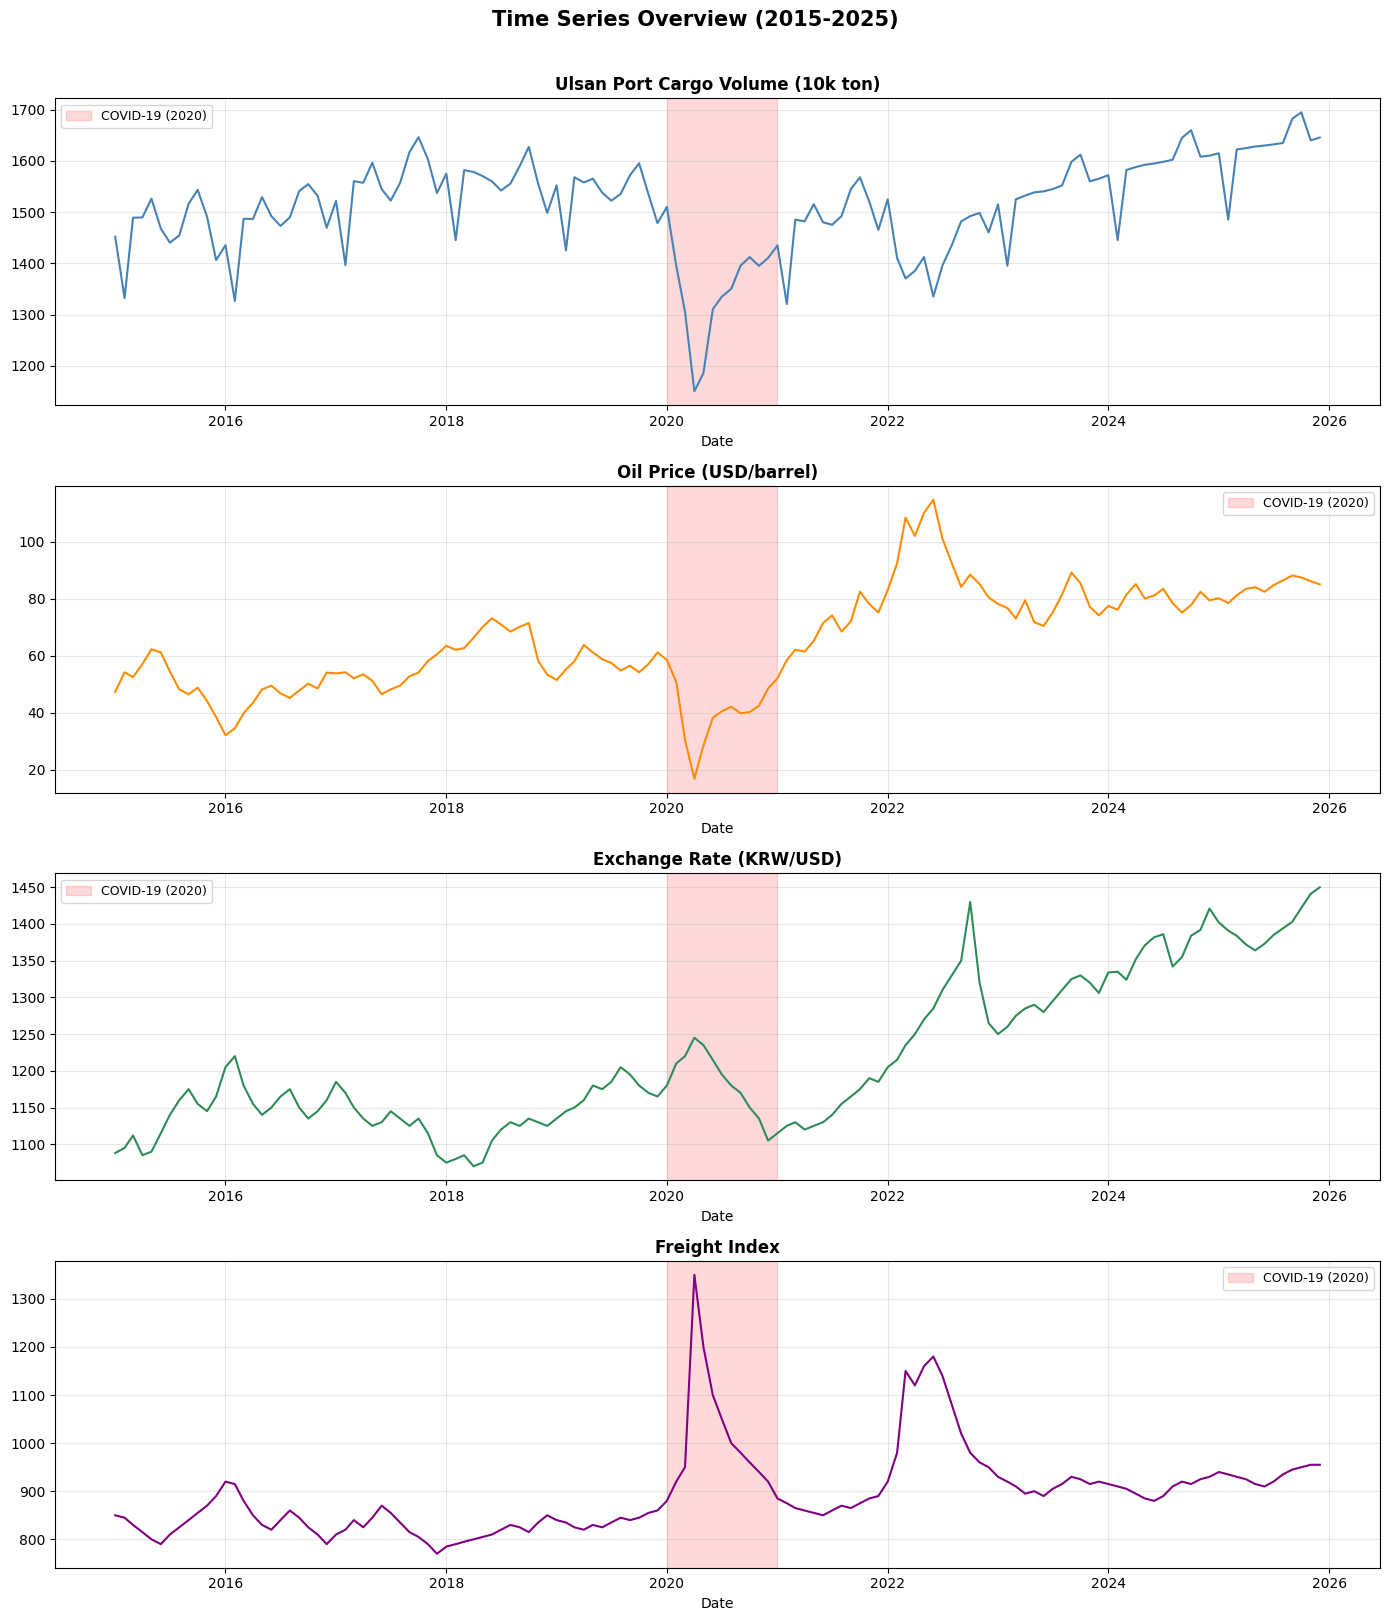


[그래프 해석 체크리스트]
□ Ulsan: 전반적으로 어떤 방향인가? 2020년 충격이 보이는가?
□ Oil Price: 어느 시점에서 가장 크게 떨어졌는가?
□ Exchange Rate: 방향성(추세)이 있는가?
□ Freight Index: 2020년에 어떤 움직임이 있는가?


In [13]:


# %%
# ============================================================
# 10회차 실습 코드 - 파트 2: 시계열 기초 & 정상성
# "시간이 흐르면 뭐가 달라지나?"
# ============================================================
# 파트 1 코드를 먼저 실행한 뒤 이어서 실행하세요.
# df 변수가 이미 불러와져 있어야 합니다.
# ============================================================

# %% [셀 8] 시계열 시각화 - 전체 변수 한눈에 보기
# -----------------------------------------------------------
# 분석 전에 데이터를 눈으로 먼저 봅니다.
# 추세, 계절성, 이상한 구간이 있는지 확인하는 것이 목적입니다.
#
# [보는 포인트]
# - 전반적으로 올라가거나 내려가는가? (추세)
# - 주기적으로 오르내리는 패턴이 있는가? (계절성)
# - 어느 시점에서 갑자기 튀는가? (이상치, 구조 변화)

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# 그릴 변수와 색상 정의
plot_vars = [
    ('Ulsan',        'steelblue',  'Ulsan Port Cargo Volume (10k ton)'),
    ('Oil_Price',  'darkorange', 'Oil Price (USD/barrel)'),
    ('Ex_Rate',    'seagreen',   'Exchange Rate (KRW/USD)'),
    ('Freight_Idx','purple',     'Freight Index'),
]

for ax, (col, color, title) in zip(axes, plot_vars):
    ax.plot(df['Date'], df[col], color=color, linewidth=1.5)

    # 2020년 코로나 구간 음영 표시
    covid_start = pd.Timestamp('2020-01-01')
    covid_end   = pd.Timestamp('2020-12-31')
    ax.axvspan(covid_start, covid_end,
               alpha=0.15, color='red', label='COVID-19 (2020)')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Time Series Overview (2015-2025)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n[그래프 해석 체크리스트]")
print("□ Ulsan: 전반적으로 어떤 방향인가? 2020년 충격이 보이는가?")
print("□ Oil Price: 어느 시점에서 가장 크게 떨어졌는가?")
print("□ Exchange Rate: 방향성(추세)이 있는가?")
print("□ Freight Index: 2020년에 어떤 움직임이 있는가?")


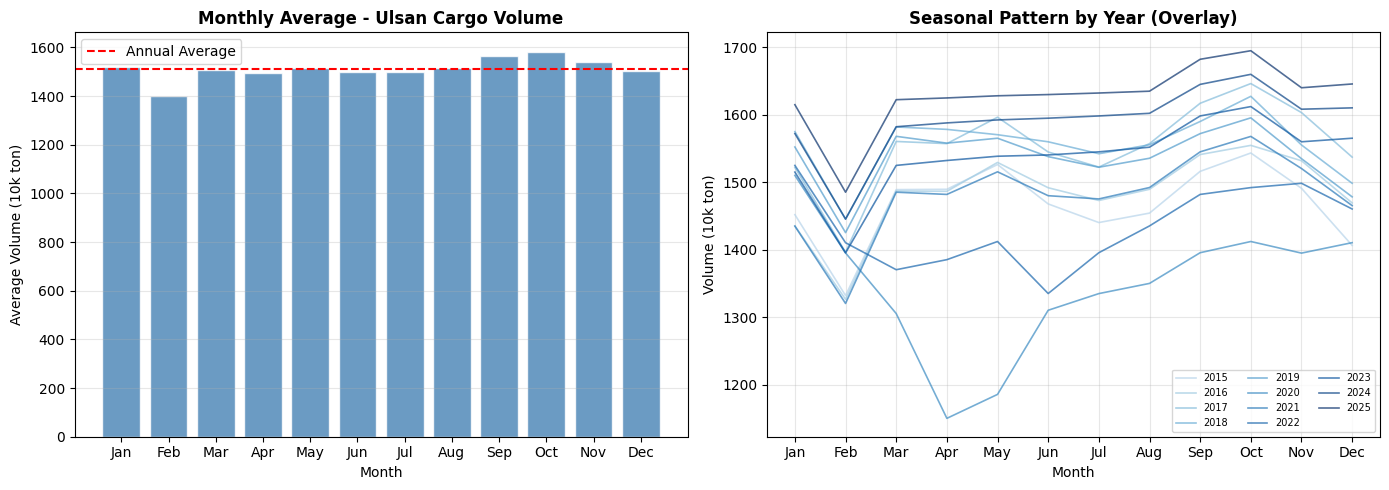

=== 월별 평균 물동량 ===
 1월:  1519.1  ████████████████████████
 2월:  1398.1  
 3월:  1507.1  █████████████████████
 4월:  1494.0  ███████████████████
 5월:  1514.7  ███████████████████████
 6월:  1499.5  ████████████████████
 7월:  1498.5  ████████████████████
 8월:  1514.6  ███████████████████████
 9월:  1562.4  ████████████████████████████████
10월:  1582.5  ████████████████████████████████████
11월:  1540.0  ████████████████████████████
12월:  1504.4  █████████████████████

최고월: 10월 (1582.5)
최저월: 2월 (1398.1)
계절 진폭(최대-최소): 184.4


In [14]:

# %% [셀 9] 계절성 확인 - 월별 평균 패턴
# -----------------------------------------------------------
# 시계열 데이터에는 매년 비슷한 시기에 반복되는 패턴(계절성)이 있을 수 있습니다.
# 월별로 평균을 내서 이 패턴이 존재하는지 확인합니다.

df['Month'] = df['Date'].dt.month   # 날짜에서 월(1~12)만 추출
df['Year']  = df['Date'].dt.year    # 날짜에서 연도만 추출

# 월별 물동량 평균 계산
monthly_avg = df.groupby('Month')['Ulsan'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 왼쪽: 월별 평균 막대 그래프 ---
axes[0].bar(monthly_avg.index, monthly_avg.values,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(y=monthly_avg.mean(), color='red',
                linestyle='--', linewidth=1.5, label='Annual Average')
axes[0].set_title('Monthly Average - Ulsan Cargo Volume',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Volume (10k ton)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# --- 오른쪽: 연도별 라인 (여러 해를 겹쳐서 계절성 패턴 반복 확인) ---
colors_yr = plt.cm.Blues(np.linspace(0.3, 1.0, df['Year'].nunique()))
for i, (year, grp) in enumerate(df.groupby('Year')):
    axes[1].plot(grp['Month'], grp['Ulsan'],
                 color=colors_yr[i], linewidth=1.2, alpha=0.7, label=str(year))

axes[1].set_title('Seasonal Pattern by Year (Overlay)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Volume (10k ton)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend(fontsize=7, ncol=3, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 수치로도 확인
print("=== 월별 평균 물동량 ===")
for m, v in monthly_avg.items():
    bar = '█' * int((v - monthly_avg.min()) / 5)
    print(f"{m:2d}월: {v:7.1f}  {bar}")
print(f"\n최고월: {monthly_avg.idxmax()}월 ({monthly_avg.max():.1f})")
print(f"최저월: {monthly_avg.idxmin()}월 ({monthly_avg.min():.1f})")
print(f"계절 진폭(최대-최소): {monthly_avg.max() - monthly_avg.min():.1f}")


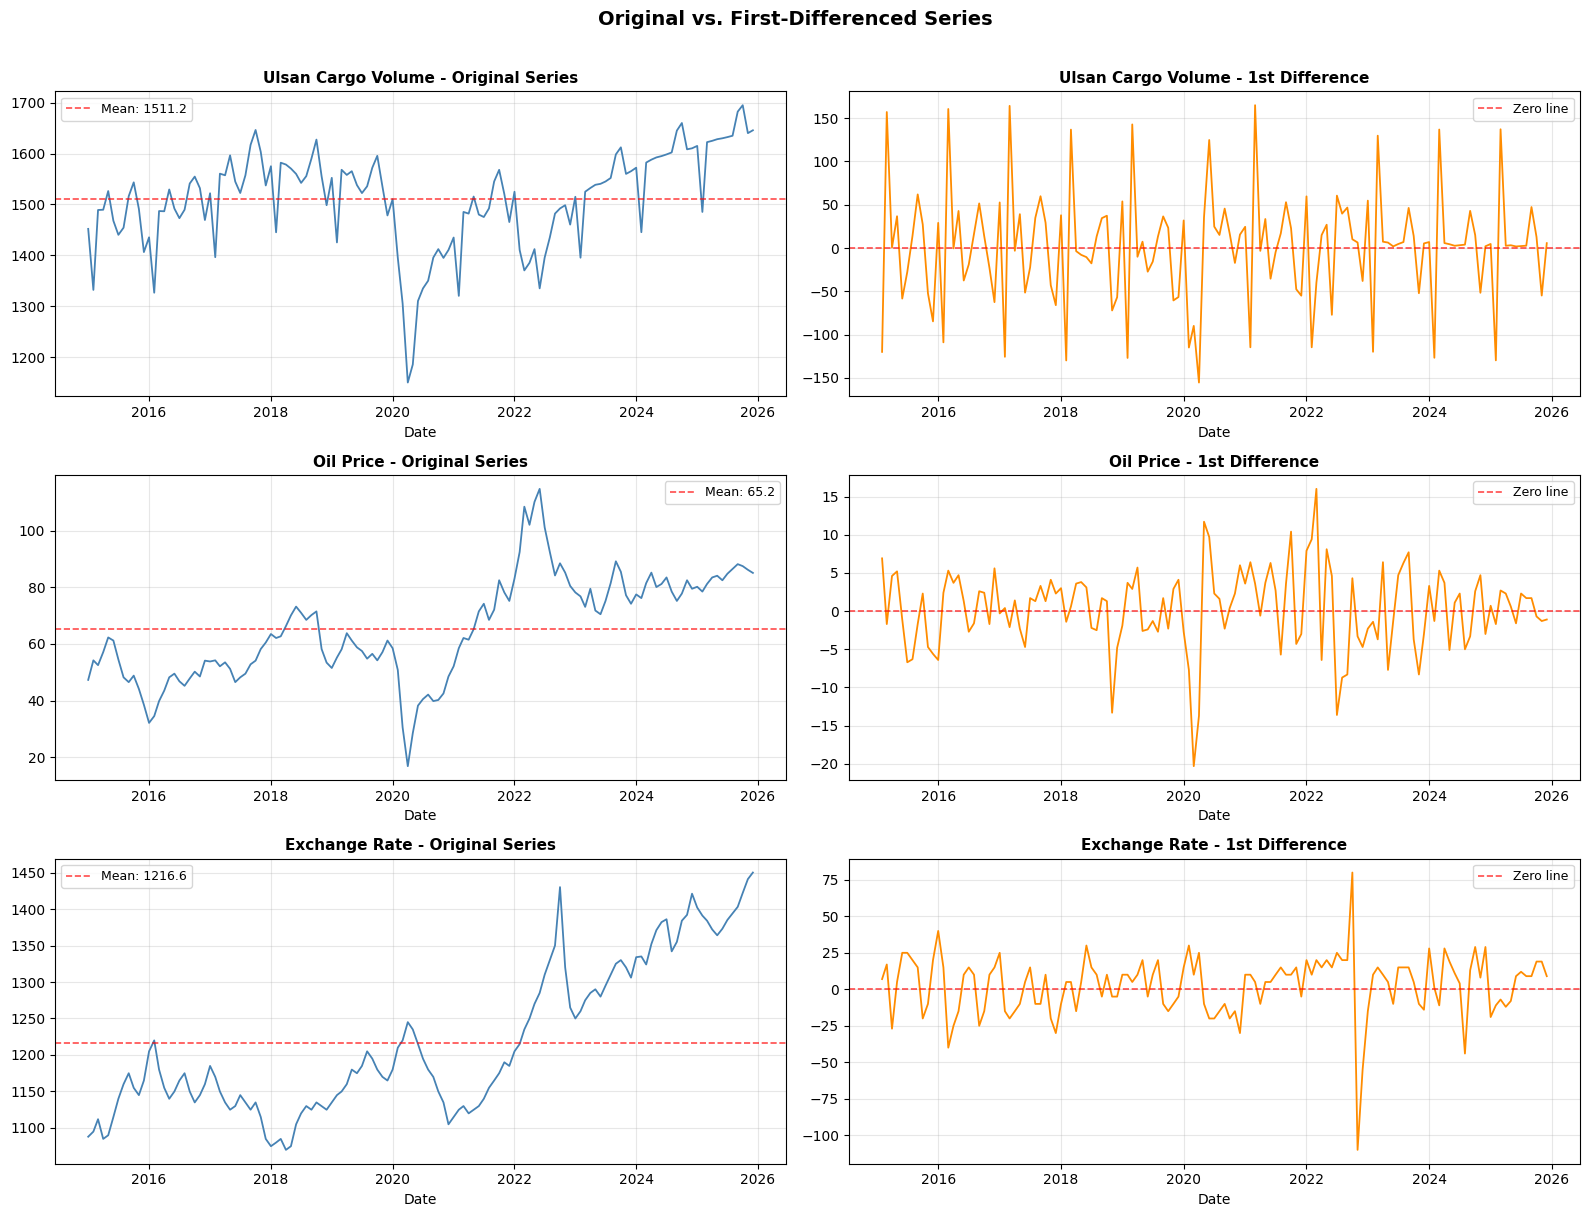


[왼쪽-오른쪽 비교 포인트]
왼쪽(원계열): 추세가 있는가? 평균선 근처에서 진동하는가?
오른쪽(차분): 0 근처에서 진동하는가? 훨씬 안정적으로 보이는가?


In [15]:

# %% [셀 10] 정상성 눈으로 확인 - 원계열 vs 차분 비교
# -----------------------------------------------------------
# ADF 검정을 하기 전에 눈으로 먼저 봅니다.
# 정상 시계열은 일정한 띠 안에서 진동하는 모습입니다.
# 비정상 시계열은 전반적으로 올라가거나 내려가는 추세를 가집니다.
#
# 차분(Differencing)이란?
# 이번 달 값에서 지난 달 값을 뺀 것입니다.
# 차분값 = 이번 달 - 지난 달
# 추세를 제거하고 "변화량"만 남깁니다.

# 분석할 변수들
target_vars = {
    'Ulsan':        'Ulsan Cargo Volume',
    'Oil_Price':  'Oil Price',
    'Ex_Rate':    'Exchange Rate',
}

fig, axes = plt.subplots(len(target_vars), 2, figsize=(16, 12))

for i, (col, label) in enumerate(target_vars.items()):

    # 원계열 (차분 전)
    axes[i, 0].plot(df['Date'], df[col],
                    color='steelblue', linewidth=1.3)

    # 평균선 추가 (정상이라면 이 선 근처에서 진동해야 함)
    mean_val = df[col].mean()
    axes[i, 0].axhline(y=mean_val, color='red',
                       linestyle='--', linewidth=1.2, alpha=0.7,
                       label=f'Mean: {mean_val:.1f}')
    axes[i, 0].set_title(f'{label} - Original Series',
                          fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('Date')
    axes[i, 0].legend(fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)

    # 1차 차분값
    diff_series = df[col].diff()   # .diff() = 이번 값 - 바로 전 값
    axes[i, 1].plot(df['Date'], diff_series,
                    color='darkorange', linewidth=1.3)
    axes[i, 1].axhline(y=0, color='red',
                       linestyle='--', linewidth=1.2, alpha=0.7,
                       label='Zero line')
    axes[i, 1].set_title(f'{label} - 1st Difference',
                          fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('Date')
    axes[i, 1].legend(fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Original vs. First-Differenced Series',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n[왼쪽-오른쪽 비교 포인트]")
print("왼쪽(원계열): 추세가 있는가? 평균선 근처에서 진동하는가?")
print("오른쪽(차분): 0 근처에서 진동하는가? 훨씬 안정적으로 보이는가?")


In [18]:

# %% [셀 11] ADF 단위근 검정 - 정상성을 숫자로 확인
# -----------------------------------------------------------
# 눈으로 본 것을 통계적으로 검증합니다.
#
# ADF 검정 해석 규칙 (외워두세요):
# ┌─────────────────────────────────────────┐
# │  p-value < 0.05  →  정상 시계열  ✅    │
# │  p-value ≥ 0.05  →  비정상 시계열 ❌   │
# └─────────────────────────────────────────┘
#
# 귀무가설: "단위근이 있다 = 비정상이다"
# p가 작으면 귀무가설 기각 → 정상
# p가 크면 귀무가설 채택 → 비정상 → 차분 필요

from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    """
    ADF 검정을 실행하고 결과를 보기 좋게 출력하는 함수입니다.
    series: 검정할 시계열 데이터
    name: 변수 이름 (출력용)
    """
    result = adfuller(series.dropna(), autolag='AIC')
    # autolag='AIC': 시차 수를 자동으로 최적 선택

    p_value  = result[1]        # p-value
    adf_stat = result[0]        # ADF 통계량
    n_lags   = result[2]        # 사용된 시차 수

    # 판정
    if p_value < 0.05:
        judgment = "✅ 정상 시계열  (p < 0.05, 단위근 없음)"
    else:
        judgment = "❌ 비정상 시계열 (p ≥ 0.05, 단위근 있음 → 차분 필요)"

    print(f"[{name}]")
    print(f"  ADF 통계량 : {adf_stat:.4f}")
    print(f"  p-value    : {p_value:.4f}")
    print(f"  사용 시차  : {n_lags}")
    print(f"  판정       : {judgment}")
    print()

    return p_value   # 나중에 비교할 수 있도록 p값 반환

# --- 원계열 ADF 검정 ---
print("=" * 55)
print("  [원계열 ADF 검정]")
print("=" * 55)

check_vars = ['Ulsan', 'Oil_Price', 'Ex_Rate', 'Freight_Idx']

p_original = {}
for col in check_vars:
    p_original[col] = run_adf(df[col], col)

# --- 1차 차분 후 ADF 검정 ---
print("=" * 55)
print("  [1차 차분 후 ADF 검정]")
print("=" * 55)

p_diff = {}
for col in check_vars:
    p_diff[col] = run_adf(df[col].diff(), f'd({col})')


  [원계열 ADF 검정]
[Ulsan]
  ADF 통계량 : -1.4987
  p-value    : 0.5342
  사용 시차  : 13
  판정       : ❌ 비정상 시계열 (p ≥ 0.05, 단위근 있음 → 차분 필요)

[Oil_Price]
  ADF 통계량 : -1.7396
  p-value    : 0.4108
  사용 시차  : 2
  판정       : ❌ 비정상 시계열 (p ≥ 0.05, 단위근 있음 → 차분 필요)

[Ex_Rate]
  ADF 통계량 : -0.7590
  p-value    : 0.8309
  사용 시차  : 1
  판정       : ❌ 비정상 시계열 (p ≥ 0.05, 단위근 있음 → 차분 필요)

[Freight_Idx]
  ADF 통계량 : -2.8491
  p-value    : 0.0516
  사용 시차  : 0
  판정       : ❌ 비정상 시계열 (p ≥ 0.05, 단위근 있음 → 차분 필요)

  [1차 차분 후 ADF 검정]
[d(Ulsan)]
  ADF 통계량 : -3.0697
  p-value    : 0.0289
  사용 시차  : 13
  판정       : ✅ 정상 시계열  (p < 0.05, 단위근 없음)

[d(Oil_Price)]
  ADF 통계량 : -8.3139
  p-value    : 0.0000
  사용 시차  : 1
  판정       : ✅ 정상 시계열  (p < 0.05, 단위근 없음)

[d(Ex_Rate)]
  ADF 통계량 : -9.2012
  p-value    : 0.0000
  사용 시차  : 0
  판정       : ✅ 정상 시계열  (p < 0.05, 단위근 없음)

[d(Freight_Idx)]
  ADF 통계량 : -11.1924
  p-value    : 0.0000
  사용 시차  : 0
  판정       : ✅ 정상 시계열  (p < 0.05, 단위근 없음)



In [19]:

# %% [셀 12] ADF 결과 정리표
# -----------------------------------------------------------
# 앞에서 나온 결과를 한눈에 보기 좋은 표로 정리합니다.
# 이 표가 논문 분석에서 "단위근 검정 결과" 표의 기초가 됩니다.

print("=" * 65)
print(f"{'변수':<20} {'원계열 p':>10} {'원계열':>12} {'차분 p':>10} {'차분':>12}")
print("-" * 65)

for col in check_vars:
    orig_p    = p_original[col]
    diff_p    = p_diff[col]
    orig_mark = "정상 ✅" if orig_p < 0.05 else "비정상 ❌"
    diff_mark = "정상 ✅" if diff_p < 0.05 else "비정상 ❌"
    print(f"{col:<20} {orig_p:>10.4f} {orig_mark:>12} {diff_p:>10.4f} {diff_mark:>12}")

print("=" * 65)
print()
print("[읽는 법]")
print("원계열이 비정상(❌)이고 차분 후 정상(✅)이면 → I(1) 시계열")
print("이 경우 VAR 분석 전에 차분 변환이 필요합니다.")
print("(단, 공적분 관계가 있다면 VECM을 써야 합니다 → 11회차에서 다룹니다)")


변수                        원계열 p          원계열       차분 p           차분
-----------------------------------------------------------------
Ulsan                    0.5342        비정상 ❌     0.0289         정상 ✅
Oil_Price                0.4108        비정상 ❌     0.0000         정상 ✅
Ex_Rate                  0.8309        비정상 ❌     0.0000         정상 ✅
Freight_Idx              0.0516        비정상 ❌     0.0000         정상 ✅

[읽는 법]
원계열이 비정상(❌)이고 차분 후 정상(✅)이면 → I(1) 시계열
이 경우 VAR 분석 전에 차분 변환이 필요합니다.
(단, 공적분 관계가 있다면 VECM을 써야 합니다 → 11회차에서 다룹니다)


In [20]:

# %% [셀 13] 오늘 수업 전체 요약 출력
# -----------------------------------------------------------
# 오늘 분석한 내용을 한 화면에 정리합니다.

print()
print("=" * 60)
print("       10회차 실습 결과 요약")
print("=" * 60)
print()
print("[ 파트 1: 회귀 진단 ]")
print(f"  기본 모델 R²           : {model.rsquared:.4f}")
print(f"  더미 추가 모델 R²      : {model_dummy.rsquared:.4f}")
print(f"  Durbin-Watson 통계량   : {durbin_watson(model.resid):.4f}")
dw = durbin_watson(model.resid)
if dw < 1.5:
    print(f"  → 자기상관 있음 (DW={dw:.2f}, 기준 2에서 멀리 떨어짐)")
else:
    print(f"  → 자기상관 없음 (DW={dw:.2f})")
print()
print("[ 파트 2: 시계열 & 정상성 ]")
for col in check_vars:
    orig = "정상" if p_original[col] < 0.05 else "비정상"
    diff = "정상" if p_diff[col]    < 0.05 else "비정상"
    integ = "I(0)" if orig == "정상" else ("I(1)" if diff == "정상" else "I(2)+")
    print(f"  {col:<18}: 원계열={orig}  차분후={diff}  → {integ}")
print()
print("[ 다음 회차 (11회차) 예고 ]")
print("  오늘 확인한 I(1) 변수들을 가지고")
print("  VAR 모델을 만들어 '변수 간 시차 영향'을 분석합니다.")
print("  '유가가 오르면 몇 달 뒤 물동량이 어떻게 변하는가?'")
print("=" * 60)


       10회차 실습 결과 요약

[ 파트 1: 회귀 진단 ]
  기본 모델 R²           : 0.1557
  더미 추가 모델 R²      : 0.3617
  Durbin-Watson 통계량   : 0.5275
  → 자기상관 있음 (DW=0.53, 기준 2에서 멀리 떨어짐)

[ 파트 2: 시계열 & 정상성 ]
  Ulsan             : 원계열=비정상  차분후=정상  → I(1)
  Oil_Price         : 원계열=비정상  차분후=정상  → I(1)
  Ex_Rate           : 원계열=비정상  차분후=정상  → I(1)
  Freight_Idx       : 원계열=비정상  차분후=정상  → I(1)

[ 다음 회차 (11회차) 예고 ]
  오늘 확인한 I(1) 변수들을 가지고
  VAR 모델을 만들어 '변수 간 시차 영향'을 분석합니다.
  '유가가 오르면 몇 달 뒤 물동량이 어떻게 변하는가?'


추가

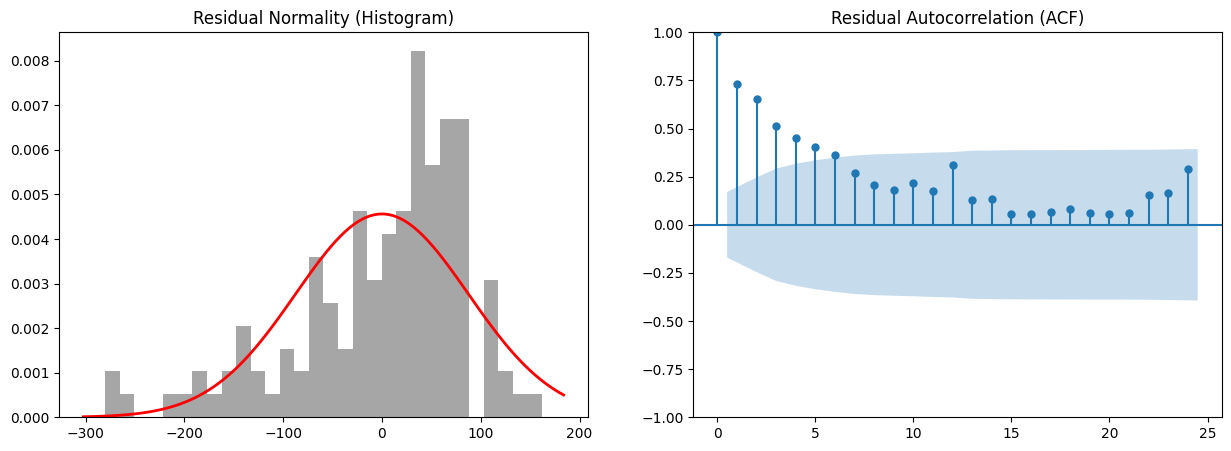

In [21]:
# %% [추가 셀] 잔차의 정규성 및 ACF 확인
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 잔차 히스토그램 (정규성 확인)
axes[0].hist(residuals, bins=30, color='gray', alpha=0.7, density=True)
# 정규분포 곡선 겹쳐 그리기
mu, std = stats.norm.fit(residuals)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'r', linewidth=2)
axes[0].set_title('Residual Normality (Histogram)')

# 2. ACF 그래프 (자기상관 시각화)
plot_acf(residuals, ax=axes[1], lags=24) # 24개월 시차까지 확인
axes[1].set_title('Residual Autocorrelation (ACF)')

plt.show()

In [22]:
# -----------------------------------------------------------
# [모델 A] 원계열(Level) 회귀분석
# -----------------------------------------------------------
X_orig = sm.add_constant(df[['Oil_Price', 'Ex_Rate']])
y_orig = df['Ulsan']
model_orig = sm.OLS(y_orig, X_orig).fit()
dw_orig = durbin_watson(model_orig.resid)

# -----------------------------------------------------------
# [모델 B] 1차 차분(Difference) 회귀분석
# -----------------------------------------------------------
# .diff()를 수행하면 첫 행은 NaN이 되므로 dropna()로 제거
df_diff = df[['Ulsan', 'Oil_Price', 'Ex_Rate']].diff().dropna()

X_diff = sm.add_constant(df_diff[['Oil_Price', 'Ex_Rate']])
y_diff = df_diff['Ulsan']
model_diff = sm.OLS(y_diff, X_diff).fit()
dw_diff = durbin_watson(model_diff.resid)

# -----------------------------------------------------------
# 결과 출력 및 시각화
# -----------------------------------------------------------
print("=== Durbin-Watson 통계량 비교 ===")
print(f"1. 원계열(Level) 모델 DW    : {dw_orig:.4f}  (심각한 양의 자기상관)")
print(f"2. 차분(Difference) 모델 DW : {dw_diff:.4f}  (자기상관 대폭 개선)")
print("-" * 50)

=== Durbin-Watson 통계량 비교 ===
1. 원계열(Level) 모델 DW    : 0.5275  (심각한 양의 자기상관)
2. 차분(Difference) 모델 DW : 2.7323  (자기상관 대폭 개선)
--------------------------------------------------


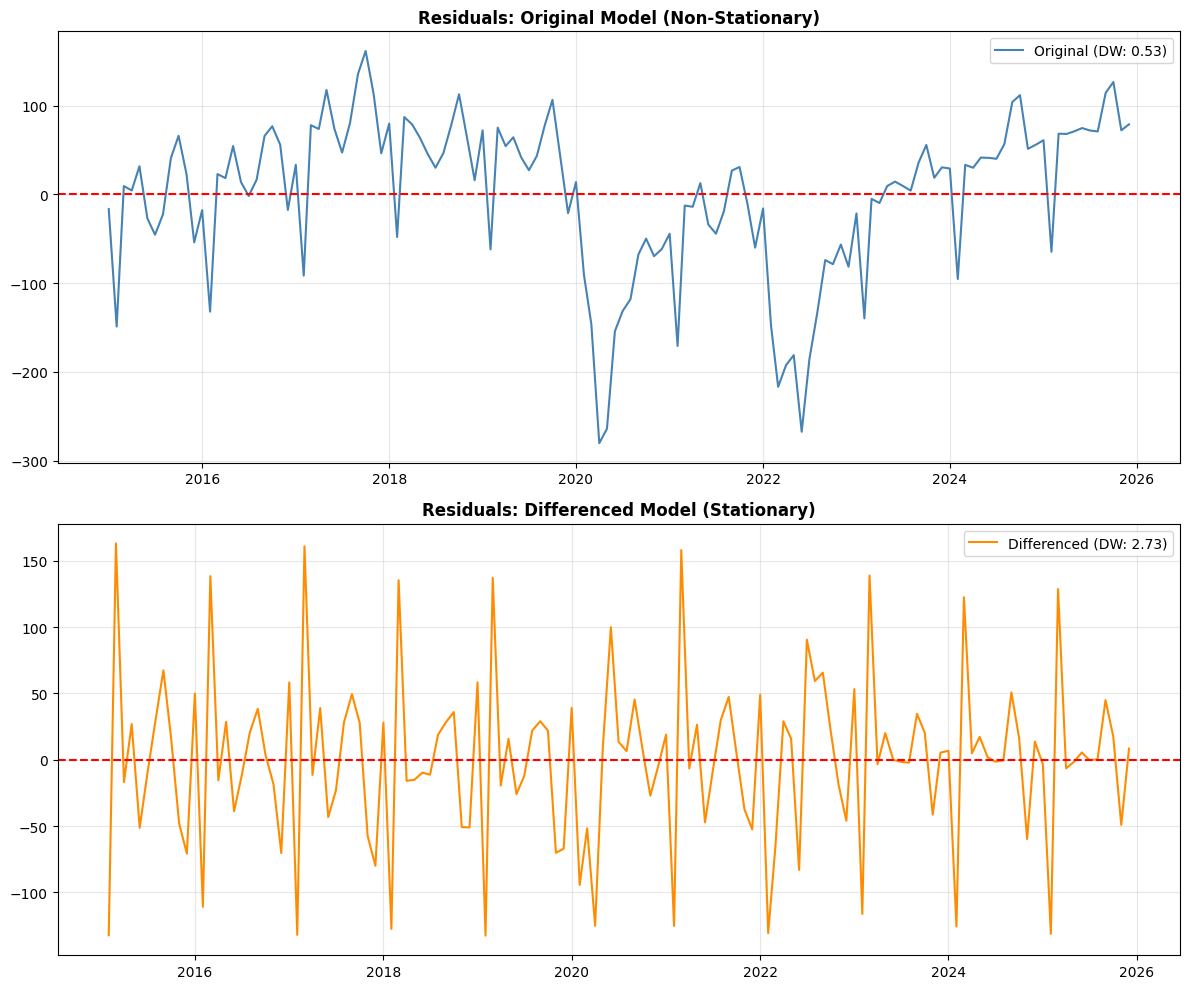

In [23]:
# 잔차 시각화 비교
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 위: 원계열 잔차 (뭉쳐 다니는 패턴 확인)
axes[0].plot(df['Date'], model_orig.resid, color='steelblue', label=f'Original (DW: {dw_orig:.2f})')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals: Original Model (Non-Stationary)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 아래: 차분계열 잔차 (무작위하게 흩어진 패턴 확인)
axes[1].plot(df['Date'][1:], model_diff.resid, color='darkorange', label=f'Differenced (DW: {dw_diff:.2f})')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals: Differenced Model (Stationary)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
model_diff.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Ulsan   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.070
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.130
Time:                        07:39:31   Log-Likelihood:                -729.29
No. Observations:                 131   AIC:                             1465.
Df Residuals:                     128   BIC:                             1473.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6960      5.658      0.300      0.765      -9.500      12.892
Oil_Price      1.8280      1.076      1.698      0.092      -0.302       3.958
Ex_Rate       -0.2695      0.272     -0.992      0.323      -0.807       0.268
==============================================================================
Omnibus:                        2.168   Durbin-Watson:                   2.732
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                1.816
Skew:                           0.103   Prob(JB):                        0.403
Kurtosis:                       3.539   Cond. No.                         21.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
model_orig.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Ulsan   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     11.89
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.82e-05
Time:                        07:40:30   Log-Likelihood:                -777.50
No. Observations:                 132   AIC:                             1561.
Df Residuals:                     129   BIC:                             1570.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1287.6780     98.566     13.064      0.000    1092.663    1482.692
Oil_Price      1.7195      0.538      3.196      0.002       0.655       2.784
Ex_Rate        0.0916      0.095      0.963      0.338      -0.097       0.280
==============================================================================
Omnibus:                       23.349   Durbin-Watson:                   0.527
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.255
Skew:                          -1.063   Prob(JB):                     4.44e-07
Kurtosis:                       3.895   Cond. No.                     1.56e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.56e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""